In [1]:
from sklearn.datasets import make_regression
from helpers import *
from filters import *
from functools import partial


In [2]:
import numpy as np
preds = np.load('./preds_mcd_af.npy')
gts = np.load('./gts_mcd_af.npy')

gts_nAF = 1-gts
gts_AF = gts
preds_nAF = preds[:,0]
preds_AF = preds[:,1]

In [3]:
test_preds = np.load('/home/cb25/hpc-work/conformal-nms/spurious-uq/mcd-ivon-ppg/checkpoints_af_mcd_sgd_0.001_1e-10_64_0.9_8_0.05/test_preds/preds_mcd_af.npy')
test_gts = np.load('/home/cb25/hpc-work/conformal-nms/spurious-uq/mcd-ivon-ppg/checkpoints_af_mcd_sgd_0.001_1e-10_64_0.9_8_0.05/test_preds/gts_mcd_af.npy')

In [4]:
test_noise_preds = np.load('/home/cb25/hpc-work/conformal-nms/spurious-uq/mcd-ivon-ppg/checkpoints_af_mcd_sgd_0.001_1e-10_64_0.9_8_0.05/noise_preds/preds_mcd_af.npy')
test_noise_gts = np.load('/home/cb25/hpc-work/conformal-nms/spurious-uq/mcd-ivon-ppg/checkpoints_af_mcd_sgd_0.001_1e-10_64_0.9_8_0.05/noise_preds/gts_mcd_af.npy')

In [5]:
test_preds_AF = test_preds[:,1]
intervals = []
for i,pred in enumerate(test_preds_AF):
    #print(i/15377)
    intervals.append(predict_interval(pred,preds_AF,gts_AF))

In [6]:
test_noise_preds_AF = test_noise_preds[:,1]
intervals_noise = []
for i,pred in enumerate(test_noise_preds_AF):
    #print(i/15377)
    intervals_noise.append(predict_interval(pred,preds_AF,gts_AF))

# DTT

## Retain only

### Original test set

/tmp/ipykernel_3776159/380047331.py:98: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_mag = np.trapz(risks_mag_filtered, retain_fractions)
/tmp/ipykernel_3776159/380047331.py:99: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_ec = np.trapz(risks_ec_filtered, retain_fractions)
/tmp/ipykernel_3776159/380047331.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucc_mag = np.trapz(expected_costs_mag_filtered, retain_fractions)
/tmp/ipykernel_3776159/380047331.py:102: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucc_ec = np.trapz(expected_costs_ec_filtered, retain_fractions)


AURC naive rule:      0.1115$
AURC cost-aware rule: 0.2025$

AUCC naive rule:      593.1815$
AUCC cost-aware rule: 514.7212$


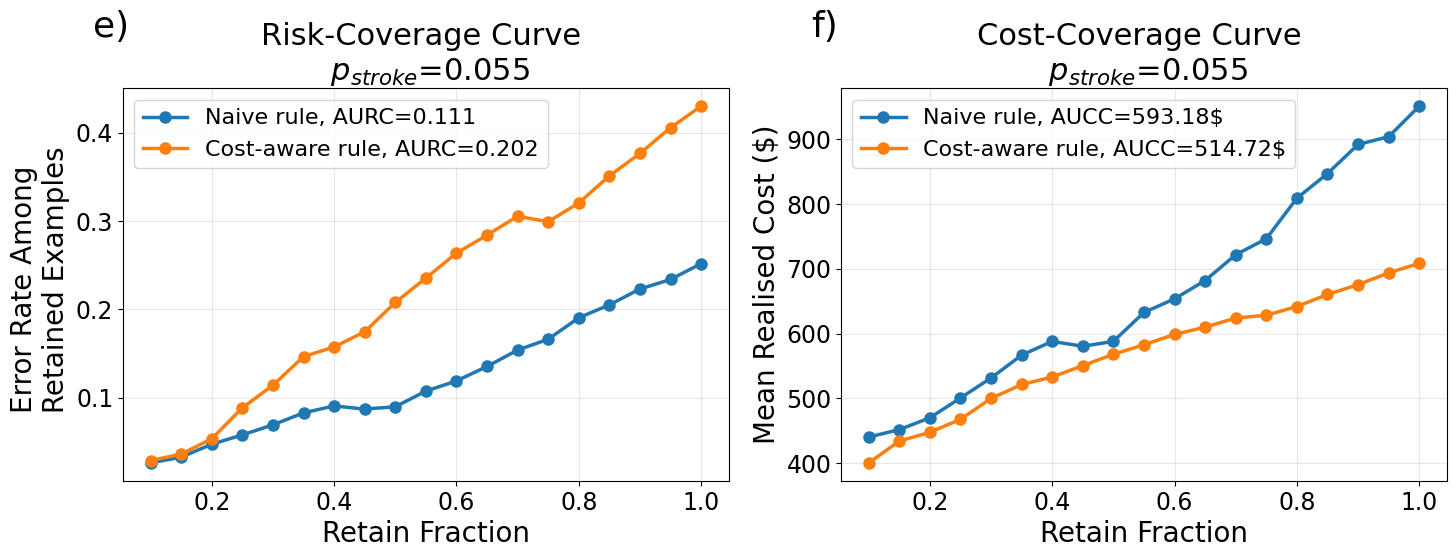

In [7]:
# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Risk-coverage / cost-coverage analysis
# ------------------------------------------------------------

retain_fractions = np.linspace(0.1, 1.0, 19)

risks_mag_filtered = []
risks_ec_filtered = []

expected_costs_mag_filtered = []
expected_costs_ec_filtered = []
cost_fn = partial(compute_single_prediction_cost,p_stroke_missed_af=0.055)

for rf in retain_fractions:

    # --------------------------------------------------------
    # Naive rule: retain by probability magnitude / confidence
    # --------------------------------------------------------
    out_mag_filtered = evaluate_va_prob_magnitude_filtering(
        intervals=np.squeeze(intervals),
        y_true=test_gts,
        retain_fraction=rf,
        pred_method="collapse",
    )

    remaining_probs_mag = out_mag_filtered["arrays"]["retained_p_hat"]
    remaining_gts_mag = out_mag_filtered["arrays"]["retained_y_true"]

    remaining_preds_mag = (remaining_probs_mag >= 0.5).astype(int)

    risk_mag = np.mean(remaining_preds_mag != remaining_gts_mag)
    risks_mag_filtered.append(risk_mag)

    cost_mag = compute_af_screening_cost(
        preds_AF,
        gts_AF,
        remaining_probs_mag,
        remaining_gts_mag,
        p_stroke_missed_af=.055,
    )["expected_cost"]

    expected_costs_mag_filtered.append(cost_mag)

    # --------------------------------------------------------
    # Cost-aware rule: reject by expected decision cost
    # --------------------------------------------------------
    out_ec_filtered = evaluate_va_expected_cost_filtering(
        intervals=np.squeeze(intervals),
        y_true=test_gts,
        cost_fn=cost_fn,
        threshold=0.218,
        reject_fraction=1 - rf,
        pred_method="collapse",
    )

    remaining_probs_ec = out_ec_filtered["arrays"]["retained_p_hat"]
    remaining_gts_ec = out_ec_filtered["arrays"]["retained_y_true"]

    remaining_preds_ec = (remaining_probs_ec >= 0.218).astype(int)

    risk_ec = np.mean(remaining_preds_ec != remaining_gts_ec)
    risks_ec_filtered.append(risk_ec)

    cost_ec = compute_af_screening_cost(
        preds_AF,
        gts_AF,
        remaining_probs_ec,
        remaining_gts_ec,
        p_stroke_missed_af=.055,
        threshold = .218,
    )["expected_cost"]

    expected_costs_ec_filtered.append(cost_ec)


# ------------------------------------------------------------
# Convert to arrays
# ------------------------------------------------------------

risks_mag_filtered = np.asarray(risks_mag_filtered)
risks_ec_filtered = np.asarray(risks_ec_filtered)

expected_costs_mag_filtered = np.asarray(expected_costs_mag_filtered)
expected_costs_ec_filtered = np.asarray(expected_costs_ec_filtered)


# ------------------------------------------------------------
# Compute summary metrics
# ------------------------------------------------------------

aurc_mag = np.trapz(risks_mag_filtered, retain_fractions)
aurc_ec = np.trapz(risks_ec_filtered, retain_fractions)

aucc_mag = np.trapz(expected_costs_mag_filtered, retain_fractions)
aucc_ec = np.trapz(expected_costs_ec_filtered, retain_fractions)

print(f"AURC naive rule:      {aurc_mag:.4f}$")
print(f"AURC cost-aware rule: {aurc_ec:.4f}$")
print()
print(f"AUCC naive rule:      {aucc_mag:.4f}$")
print(f"AUCC cost-aware rule: {aucc_ec:.4f}$")


# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

# Larger global font settings
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "figure.titlesize": 24,
})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Risk-coverage curve
axes[0].plot(
    retain_fractions,
    risks_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naive rule, AURC={aurc_mag:.3f}",
)

axes[0].plot(
    retain_fractions,
    risks_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware rule, AURC={aurc_ec:.3f}",
)

axes[0].set_xlabel("Retain Fraction", fontsize=20)
axes[0].set_ylabel("Error Rate Among \n Retained Examples", fontsize=20)
axes[0].set_title("Risk-Coverage Curve \n $p_{stroke}$=0.055", fontsize=22)
axes[0].tick_params(axis="both", labelsize=17)
axes[0].legend(fontsize=16)
axes[0].grid(True, alpha=0.3)


# Cost-coverage curve
axes[1].plot(
    retain_fractions,
    expected_costs_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naive rule, AUCC={aucc_mag:.2f}$",
)

axes[1].plot(
    retain_fractions,
    expected_costs_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware rule, AUCC={aucc_ec:.2f}$",
)

axes[1].set_xlabel("Retain Fraction", fontsize=20)
axes[1].set_ylabel("Mean Realised Cost ($)", fontsize=20)
axes[1].set_title("Cost-Coverage Curve \n $p_{stroke}$=0.055", fontsize=22)
axes[1].tick_params(axis="both", labelsize=17)
axes[1].legend(fontsize=16)
axes[1].grid(True, alpha=0.3)

# Main title
#fig.suptitle("Original Test Set", fontsize=26, y=.9)

axes[0].text(
    -0.05, 1.2, "e)",
    transform=axes[0].transAxes,
    fontsize=26,
    va="top",
    ha="left",
)

axes[1].text(
    -0.05, 1.2, "f)",
    transform=axes[1].transAxes,
    fontsize=26,
    va="top",
    ha="left",
)
# Leave room for suptitle
plt.tight_layout()
#fig.savefig("risk_cost_coverage_original_test_set_55.pdf", format="pdf", bbox_inches="tight")



plt.show()

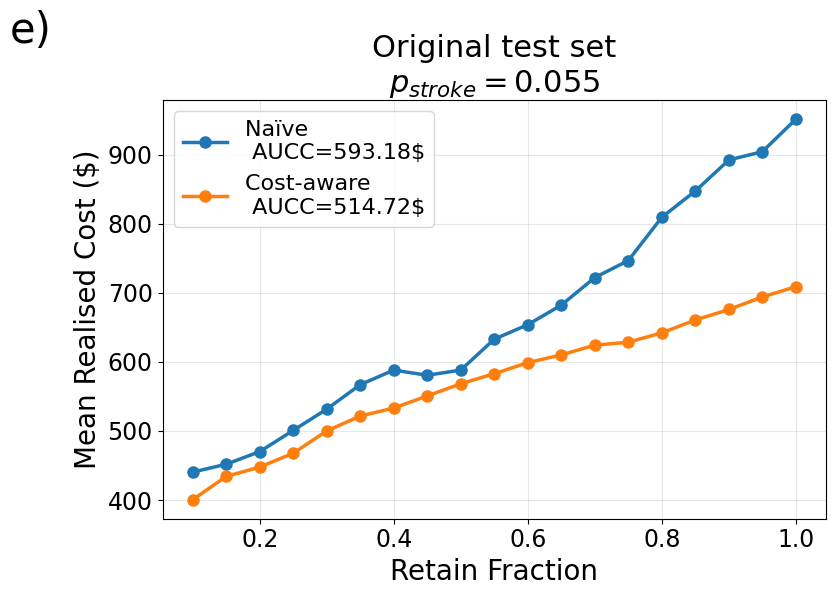

In [8]:
# ------------------------------------------------------------
# Plot cost-coverage curve only
# ------------------------------------------------------------

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "figure.titlesize": 24,
})

fig, ax = plt.subplots(figsize=(8, 6))

# Cost-coverage curve
ax.plot(
    retain_fractions,
    expected_costs_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naïve \n AUCC={aucc_mag:.2f}$",
)

ax.plot(
    retain_fractions,
    expected_costs_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware \n AUCC={aucc_ec:.2f}$",
)

ax.set_xlabel("Retain Fraction", fontsize=20)
ax.set_ylabel("Mean Realised Cost ($)", fontsize=20)
ax.set_title(
    "Original test set\n$p_{stroke}=0.055$",
    fontsize=22,
)

ax.tick_params(axis="both", labelsize=17)
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)
fig.text(
    -0.05, 1, "e)",
    #transform=axes[1].transAxes,
    fontsize=30,
    va="top",
    ha="left",
)

plt.tight_layout()

fig.savefig(
    "dtt_cost_coverage_original_test_set_55.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

### augmented test set

/tmp/ipykernel_3776159/1945018725.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_mag = np.trapz(risks_mag_filtered, retain_fractions)
/tmp/ipykernel_3776159/1945018725.py:95: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_ec = np.trapz(risks_ec_filtered, retain_fractions)
/tmp/ipykernel_3776159/1945018725.py:97: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucc_mag = np.trapz(expected_costs_mag_filtered, retain_fractions)
/tmp/ipykernel_3776159/1945018725.py:98: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucc_ec = np.trapz(expected_costs_ec_filtered, retain_fractions)


AURC naive rule:      0.5462
AURC cost-aware rule: 0.5474

AUCC naive rule:      720.1561$
AUCC cost-aware rule: 716.3463$


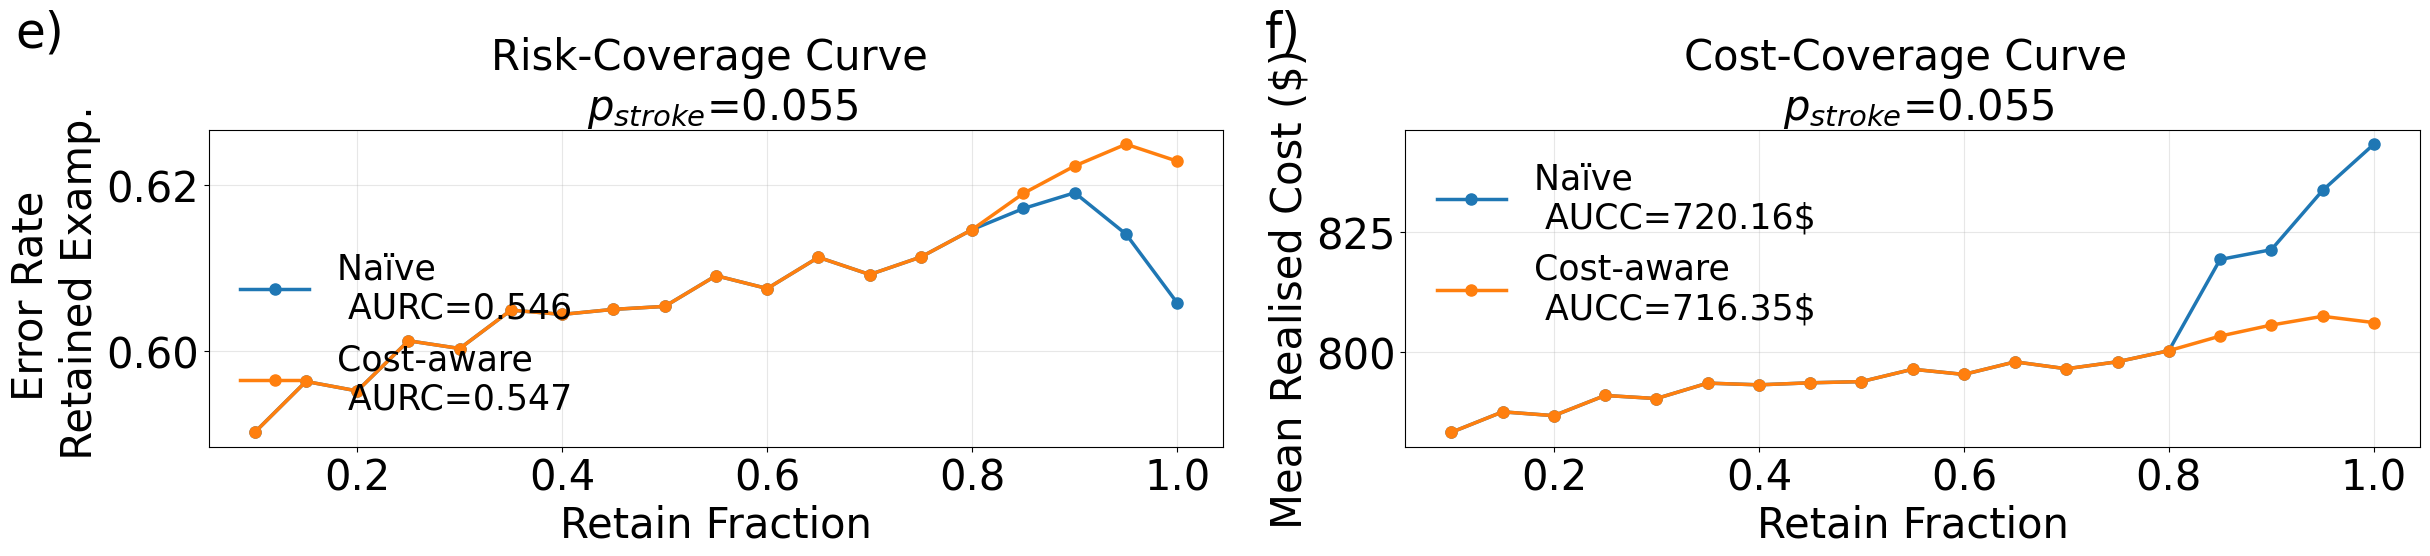

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Risk-coverage / cost-coverage analysis
# ------------------------------------------------------------

retain_fractions = np.linspace(0.1, 1.0, 19)

risks_mag_filtered = []
risks_ec_filtered = []

expected_costs_mag_filtered = []
expected_costs_ec_filtered = []
cost_fn = partial(compute_single_prediction_cost,p_stroke_missed_af=0.055)

for rf in retain_fractions:

    # --------------------------------------------------------
    # Naive rule: retain by probability magnitude / confidence
    # --------------------------------------------------------
    out_mag_filtered = evaluate_va_prob_magnitude_filtering(
        intervals=np.squeeze(intervals_noise),
        y_true=test_noise_gts,
        retain_fraction=rf,
        pred_method="collapse",
    )

    remaining_probs_mag = out_mag_filtered["arrays"]["retained_p_hat"]
    remaining_gts_mag = out_mag_filtered["arrays"]["retained_y_true"]

    remaining_preds_mag = (remaining_probs_mag >= 0.5).astype(int)

    risk_mag = np.mean(remaining_preds_mag != remaining_gts_mag)
    risks_mag_filtered.append(risk_mag)

    cost_mag = compute_af_screening_cost(
        preds_AF,
        gts_AF,
        remaining_probs_mag,
        remaining_gts_mag,
        p_stroke_missed_af=.055,
    )["expected_cost"]

    expected_costs_mag_filtered.append(cost_mag)

    # --------------------------------------------------------
    # Cost-aware rule: reject by expected decision cost
    # --------------------------------------------------------
    out_ec_filtered = evaluate_va_expected_cost_filtering(
        intervals=np.squeeze(intervals_noise),
        y_true=test_noise_gts,
        cost_fn=cost_fn,
        threshold=0.218,
        reject_fraction=1 - rf,
        pred_method="collapse",
    )

    remaining_probs_ec = out_ec_filtered["arrays"]["retained_p_hat"]
    remaining_gts_ec = out_ec_filtered["arrays"]["retained_y_true"]

    remaining_preds_ec = (remaining_probs_ec >= 0.218).astype(int)

    risk_ec = np.mean(remaining_preds_ec != remaining_gts_ec)
    risks_ec_filtered.append(risk_ec)

    cost_ec = compute_af_screening_cost(
        preds_AF,
        gts_AF,
        remaining_probs_ec,
        remaining_gts_ec,
        p_stroke_missed_af=.055,
        threshold = .218,
    )["expected_cost"]

    expected_costs_ec_filtered.append(cost_ec)


# ------------------------------------------------------------
# Convert to arrays
# ------------------------------------------------------------

risks_mag_filtered = np.asarray(risks_mag_filtered)
risks_ec_filtered = np.asarray(risks_ec_filtered)

expected_costs_mag_filtered = np.asarray(expected_costs_mag_filtered)
expected_costs_ec_filtered = np.asarray(expected_costs_ec_filtered)


# ------------------------------------------------------------
# Compute summary metrics
# ------------------------------------------------------------

aurc_mag = np.trapz(risks_mag_filtered, retain_fractions)
aurc_ec = np.trapz(risks_ec_filtered, retain_fractions)

aucc_mag = np.trapz(expected_costs_mag_filtered, retain_fractions)
aucc_ec = np.trapz(expected_costs_ec_filtered, retain_fractions)

print(f"AURC naive rule:      {aurc_mag:.4f}")
print(f"AURC cost-aware rule: {aurc_ec:.4f}")
print()
print(f"AUCC naive rule:      {aucc_mag:.4f}$")
print(f"AUCC cost-aware rule: {aucc_ec:.4f}$")


# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

# Larger global font settings
plt.rcParams.update({
    "font.size": 30,
    "axes.titlesize": 30,
    "axes.labelsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "legend.fontsize": 30,
    "figure.titlesize": 30,
})

fig, axes = plt.subplots(1, 2, figsize=(25, 6))

# Risk-coverage curve
axes[0].plot(
    retain_fractions,
    risks_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naïve \n AURC={aurc_mag:.3f}",
)

axes[0].plot(
    retain_fractions,
    risks_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware \n AURC={aurc_ec:.3f}",
)

axes[0].set_xlabel("Retain Fraction")#, fontsize=20)
axes[0].set_ylabel("Error Rate \n Retained Examp.")#, fontsize=20)
axes[0].set_title("Risk-Coverage Curve \n $p_{stroke}$=0.055")#, fontsize=22)
axes[0].tick_params(axis="both")#, labelsize=17)
axes[0].legend(fontsize=35)
axes[0].grid(True, alpha=0.3)


# Cost-coverage curve
axes[1].plot(
    retain_fractions,
    expected_costs_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naïve \n AUCC={aucc_mag:.2f}$",
)

axes[1].plot(
    retain_fractions,
    expected_costs_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware \n AUCC={aucc_ec:.2f}$",
)

axes[1].set_xlabel("Retain Fraction")#, fontsize=20)
axes[1].set_ylabel("Mean Realised Cost ($)")#, fontsize=20)
axes[1].set_title("Cost-Coverage Curve \n $p_{stroke}$=0.055")#, fontsize=22)
axes[1].tick_params(axis="both")#, labelsize=17)
axes[1].legend(fontsize=30)
axes[1].grid(True, alpha=0.3)

# Main title
#fig.suptitle("Augmented Test Set", fontsize=35, y=.9, x=.43)

fig.text(
    0.02, 0.97, "e)",
    #transform=axes[0].transAxes,
    fontsize=35,
    va="top",
    ha="left",
)

fig.text(
    0.52, 0.97, "f)",
    #transform=axes[1].transAxes,
    fontsize=35,
    va="top",
    ha="left",
)

axes[0].legend(
    fontsize=25,
    loc="lower left",
    #bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

axes[1].legend(
    fontsize=25,
    loc="upper left",
    #bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)
# Leave room for suptitle
# Leave room for suptitle
plt.tight_layout()

plt.show()

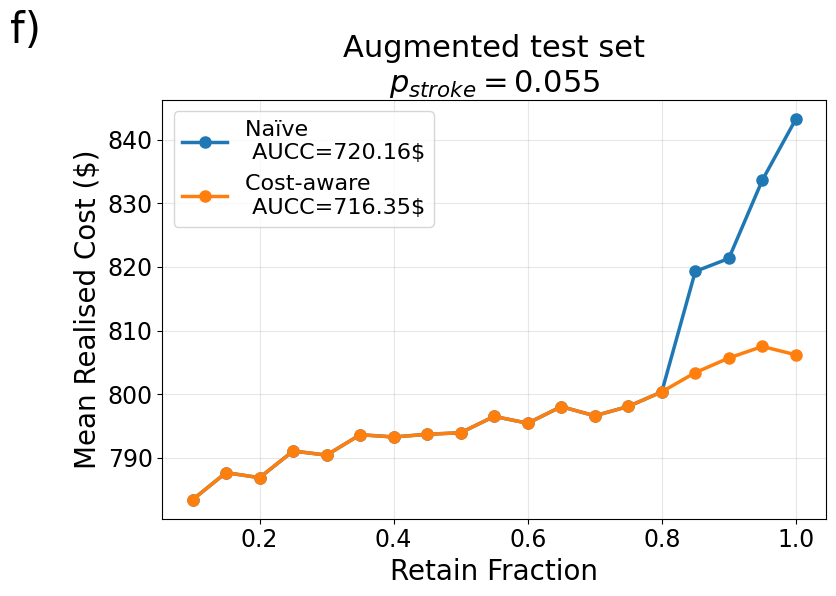

In [10]:
# ------------------------------------------------------------
# Plot cost-coverage curve only
# ------------------------------------------------------------

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "figure.titlesize": 24,
})

fig, ax = plt.subplots(figsize=(8, 6))

# Cost-coverage curve
ax.plot(
    retain_fractions,
    expected_costs_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naïve \n AUCC={aucc_mag:.2f}$",
)

ax.plot(
    retain_fractions,
    expected_costs_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware \n AUCC={aucc_ec:.2f}$",
)

ax.set_xlabel("Retain Fraction", fontsize=20)
ax.set_ylabel("Mean Realised Cost ($)", fontsize=20)
ax.set_title(
    "Augmented test set\n$p_{stroke}=0.055$",
    fontsize=22,
)

ax.tick_params(axis="both", labelsize=17)
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)
fig.text(
    -0.05, 1, "f)",
    #transform=axes[1].transAxes,
    fontsize=30,
    va="top",
    ha="left",
)

plt.tight_layout()

fig.savefig(
    "dtt_cost_coverage_augmented_test_set_55.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

# error composition

In [11]:
out_mag_filtered = evaluate_va_prob_magnitude_filtering(
    intervals=np.squeeze(intervals_noise),
    y_true=test_noise_gts,
    retain_fraction=0.5,
    pred_method="collapse",
)

def print_confusion_percentages(out, subset,tag):
    tp = out[subset]["tp"]
    fp = out[subset]["fp"]
    tn = out[subset]["tn"]
    fn = out[subset]["fn"]

    total = tp + fp + tn + fn

    print(f"\n{subset.upper()}")
    print(f"\n{tag.upper()}")
    print("-" * 30)
    print(f"Total: {total}")

    if total == 0:
        print("No examples in this subset.")
        return
    
    print(f"TP: {tp} ({100 * tp / total:.2f}%)")
    print(f"FP: {fp} ({100 * fp / total:.2f}%)")
    print(f"TN: {tn} ({100 * tn / total:.2f}%)")
    print(f"FN: {fn} ({100 * fn / total:.2f}%)")


print_confusion_percentages(out_mag_filtered, "overall",'Prob filter noisy')
print_confusion_percentages(out_mag_filtered, "rejected",'Prob filter noisy')
print_confusion_percentages(out_mag_filtered, "retained",'Prob retained noisy')


OVERALL

PROB FILTER NOISY
------------------------------
Total: 15377
TP: 5374 (34.95%)
FP: 8892 (57.83%)
TN: 688 (4.47%)
FN: 423 (2.75%)

REJECTED

PROB FILTER NOISY
------------------------------
Total: 7689
TP: 2340 (30.43%)
FP: 4238 (55.12%)
TN: 688 (8.95%)
FN: 423 (5.50%)

RETAINED

PROB RETAINED NOISY
------------------------------
Total: 7688
TP: 3034 (39.46%)
FP: 4654 (60.54%)
TN: 0 (0.00%)
FN: 0 (0.00%)


In [12]:
cost_fn = partial(compute_single_prediction_cost,p_stroke_missed_af=0.055)

out_ec_filtered = evaluate_va_expected_cost_filtering(
    intervals=np.squeeze(intervals_noise),
    y_true=test_noise_gts,
    cost_fn=cost_fn,
    threshold=.218,
    reject_fraction=0.50,
    pred_method="collapse",
)



print_confusion_percentages(out_ec_filtered, "overall",'ec filtered noisy')
print_confusion_percentages(out_ec_filtered, "rejected",'ec filtered noisy')
print_confusion_percentages(out_ec_filtered, "retained",'ec retained noisy')


OVERALL

EC FILTERED NOISY
------------------------------
Total: 15377
TP: 5796 (37.69%)
FP: 9578 (62.29%)
TN: 2 (0.01%)
FN: 1 (0.01%)

REJECTED

EC FILTERED NOISY
------------------------------
Total: 7689
TP: 2762 (35.92%)
FP: 4924 (64.04%)
TN: 2 (0.03%)
FN: 1 (0.01%)

RETAINED

EC RETAINED NOISY
------------------------------
Total: 7688
TP: 3034 (39.46%)
FP: 4654 (60.54%)
TN: 0 (0.00%)
FN: 0 (0.00%)


In [13]:
cost_fn = partial(compute_single_prediction_cost,p_stroke_missed_af=0.055)

out_ec_filtered = evaluate_va_expected_cost_filtering(
    intervals=np.squeeze(intervals),
    y_true=test_gts,
    cost_fn=cost_fn,
    threshold=0.218,
    reject_fraction=0.5,
    pred_method="collapse",
)




print_confusion_percentages(out_ec_filtered, "overall",'ec filtered clean')
print_confusion_percentages(out_ec_filtered, "rejected",'ec filtered clean')


OVERALL

EC FILTERED CLEAN
------------------------------
Total: 15377
TP: 5489 (35.70%)
FP: 6307 (41.02%)
TN: 3273 (21.29%)
FN: 308 (2.00%)

REJECTED

EC FILTERED CLEAN
------------------------------
Total: 7689
TP: 1941 (25.24%)
FP: 4919 (63.97%)
TN: 731 (9.51%)
FN: 98 (1.27%)


In [14]:
out_mag_filtered = evaluate_va_prob_magnitude_filtering(
    intervals=np.squeeze(intervals),
    y_true=test_gts,
    retain_fraction=0.5,
    pred_method="collapse",
)




print_confusion_percentages(out_mag_filtered, "overall",'prob filtered clean')
print_confusion_percentages(out_mag_filtered, "rejected",'prob filtered clean')


OVERALL

PROB FILTERED CLEAN
------------------------------
Total: 15377
TP: 2333 (15.17%)
FP: 409 (2.66%)
TN: 9171 (59.64%)
FN: 3464 (22.53%)

REJECTED

PROB FILTERED CLEAN
------------------------------
Total: 7689
TP: 1097 (14.27%)
FP: 368 (4.79%)
TN: 3408 (44.32%)
FN: 2816 (36.62%)
